# 🕸️ Module 10: LangGraph — Stateful Multi-Agent Workflows

---

## What is LangGraph?

**LangGraph** is a library for building **stateful, cyclical computation graphs** for LLM applications. It extends LangChain with:

- **State management** — persistent state across nodes
- **Cycles** — loops and conditional branching
- **Multi-agent** — multiple AI agents collaborating
- **Human-in-the-loop** — pause for human approval

### When to use LangGraph vs chains:

| Scenario | Use |
|----------|-----|
| Simple linear workflow | LCEL Chain |
| Single LLM + tools | AgentExecutor |
| Complex stateful workflow | LangGraph |
| Multiple cooperating agents | LangGraph |
| Human approval checkpoints | LangGraph |
| Loops with exit conditions | LangGraph |

---

## Core Concepts

```
StateGraph
├── State (TypedDict) — shared data between nodes
├── Nodes — Python functions or agents
├── Edges — connections between nodes
│   ├── Normal edges — always followed
│   └── Conditional edges — LLM decides which path
└── Entry/End points
```

---

In [1]:
%pip install -q langgraph

import os
from dotenv import load_dotenv
load_dotenv(dotenv_path="../.env")

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
print("Setup complete ✅")

Note: you may need to restart the kernel to use updated packages.
Setup complete ✅


## 1️⃣ Simple State Machine — Document Review

In [2]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END, START
import operator

# ============================================================
# Step 1: Define the State — shared data across all nodes
# ============================================================
class DocumentState(TypedDict):
    document: str           # The document to review
    draft: str              # Current draft
    feedback: str           # Reviewer feedback
    revision_count: int     # How many revisions done
    approved: bool          # Is it approved?
    final_document: str     # Final approved document

# ============================================================
# Step 2: Define Nodes (functions that process state)
# ============================================================
def write_draft(state: DocumentState) -> DocumentState:
    """Node 1: Write or revise the document"""
    print(f"\n✍️  Writing draft (revision #{state.get('revision_count', 0) + 1})...")
    
    if state.get('feedback'):
        # Incorporate feedback
        prompt = f"""
        Original topic: {state['document']}
        Current draft: {state.get('draft', 'N/A')}
        Feedback to address: {state['feedback']}
        
        Write an improved version addressing the feedback. Keep it to 3 sentences.
        """
    else:
        # First draft
        prompt = f"Write a 3-sentence summary about: {state['document']}"
    
    response = llm.invoke(prompt)
    
    return {
        **state,
        "draft": response.content,
        "revision_count": state.get('revision_count', 0) + 1
    }

def review_draft(state: DocumentState) -> DocumentState:
    """Node 2: Review the draft and decide if it's good"""
    print(f"\n🔍 Reviewing draft...")
    
    prompt = f"""
    Review this document draft:
    Topic: {state['document']}
    Draft: {state['draft']}
    
    If the draft is good (accurate, clear, complete), respond with: APPROVED
    If it needs improvement, respond with: NEEDS_REVISION: [specific feedback]
    """
    
    response = llm.invoke(prompt)
    review_text = response.content.strip()
    
    if "APPROVED" in review_text:
        print("  ✅ Reviewer says: APPROVED")
        return {**state, "approved": True, "feedback": ""}
    else:
        feedback = review_text.replace("NEEDS_REVISION:", "").strip()
        print(f"  ❌ Reviewer says: NEEDS REVISION\n     Feedback: {feedback[:80]}")
        return {**state, "approved": False, "feedback": feedback}

def finalize_document(state: DocumentState) -> DocumentState:
    """Node 3: Finalize the approved document"""
    print(f"\n📄 Finalizing document...")
    return {**state, "final_document": state["draft"]}

# ============================================================
# Step 3: Define conditional routing
# ============================================================
def should_revise_or_finalize(state: DocumentState) -> str:
    """Decide next step based on review outcome"""
    if state.get("approved"):
        return "finalize"          # Route to finalization
    elif state.get("revision_count", 0) >= 3:
        print("\n⚠️  Max revisions reached, forcing finalization")
        return "finalize"          # Force finalize after 3 revisions
    else:
        return "revise"            # Route back to writing

print("Nodes defined ✅")

Nodes defined ✅


In [3]:
# ============================================================
# Step 4: Build the graph
# ============================================================
workflow = StateGraph(DocumentState)

# Add nodes
workflow.add_node("write", write_draft)
workflow.add_node("review", review_draft)
workflow.add_node("finalize", finalize_document)

# Add edges (connections)
workflow.add_edge(START, "write")        # Start → Write
workflow.add_edge("write", "review")     # Write → Review

# Conditional edge: from review, go to 'revise' or 'finalize'
workflow.add_conditional_edges(
    "review",
    should_revise_or_finalize,
    {
        "revise": "write",       # Loop back to write
        "finalize": "finalize"   # Go to finalize
    }
)
workflow.add_edge("finalize", END)       # Finalize → End

# Compile the graph
app = workflow.compile()

print("Graph compiled ✅")
print("\nGraph structure:")
print("START → write → review → (conditional) → write (loop)")
print("                                       → finalize → END")

Graph compiled ✅

Graph structure:
START → write → review → (conditional) → write (loop)
                                       → finalize → END


In [4]:
# ============================================================
# Step 5: Run the graph!
# ============================================================
initial_state = {
    "document": "The benefits and risks of artificial intelligence in healthcare",
    "draft": "",
    "feedback": "",
    "revision_count": 0,
    "approved": False,
    "final_document": ""
}

print("Starting document review workflow...")
print("=" * 60)

final_state = app.invoke(initial_state)

print("\n" + "=" * 60)
print(f"WORKFLOW COMPLETE!")
print(f"Revisions: {final_state['revision_count']}")
print(f"\nFinal Document:")
print(final_state['final_document'])

Starting document review workflow...

✍️  Writing draft (revision #1)...

🔍 Reviewing draft...
  ❌ Reviewer says: NEEDS REVISION
     Feedback: The draft is a good start, but it lacks specific examples and supporting evidenc

✍️  Writing draft (revision #2)...

🔍 Reviewing draft...
  ❌ Reviewer says: NEEDS REVISION
     Feedback: The draft is generally clear and accurate, but it could be improved by providing

✍️  Writing draft (revision #3)...

🔍 Reviewing draft...
  ❌ Reviewer says: NEEDS REVISION
     Feedback: The draft is generally well-structured and clear, but it could benefit from more

⚠️  Max revisions reached, forcing finalization

📄 Finalizing document...

WORKFLOW COMPLETE!
Revisions: 3

Final Document:
The integration of artificial intelligence (AI) in healthcare has numerous benefits, including improved diagnosis accuracy, as seen in the use of AI-assisted computer vision for detecting diseases such as diabetic retinopathy, with studies showing a 90% detection rate, and 

## 2️⃣ Multi-Agent System with LangGraph

In [5]:
from typing import TypedDict, Annotated, List, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool

# ============================================================
# Multi-Agent Research System
# Agent 1: Researcher — gathers information
# Agent 2: Analyst — analyzes and structures
# Agent 3: Writer — creates final output
# ============================================================

class ResearchState(TypedDict):
    topic: str
    raw_research: str
    analysis: str
    final_report: str
    messages: Annotated[list, operator.add]  # Accumulate messages

def research_agent(state: ResearchState) -> dict:
    """Researcher: Gather facts about the topic"""
    print("🔬 Researcher working...")
    
    response = llm.invoke([
        SystemMessage(content="You are a research specialist. Gather key facts and data."),
        HumanMessage(content=f"Research this topic thoroughly: {state['topic']}. Provide 5 key facts with details.")
    ])
    
    return {
        "raw_research": response.content,
        "messages": [AIMessage(content=f"[Researcher]: {response.content[:100]}...")]
    }

def analyst_agent(state: ResearchState) -> dict:
    """Analyst: Analyze and structure the research"""
    print("📊 Analyst working...")
    
    response = llm.invoke([
        SystemMessage(content="You are a data analyst. Analyze research and identify patterns."),
        HumanMessage(content=f"""
        Topic: {state['topic']}
        Research: {state['raw_research']}
        
        Analyze this research and provide:
        1. Key trends
        2. Important implications
        3. Potential concerns
        """)
    ])
    
    return {
        "analysis": response.content,
        "messages": [AIMessage(content=f"[Analyst]: {response.content[:100]}...")]
    }

def writer_agent(state: ResearchState) -> dict:
    """Writer: Create the final comprehensive report"""
    print("✍️  Writer working...")
    
    response = llm.invoke([
        SystemMessage(content="You are a professional writer. Create clear, engaging reports."),
        HumanMessage(content=f"""
        Topic: {state['topic']}
        Research: {state['raw_research']}
        Analysis: {state['analysis']}
        
        Write a comprehensive 3-paragraph report suitable for a business audience.
        Include an executive summary, key findings, and recommendations.
        """)
    ])
    
    return {
        "final_report": response.content,
        "messages": [AIMessage(content=f"[Writer]: Report completed.")]
    }

# Build multi-agent graph
research_workflow = StateGraph(ResearchState)

research_workflow.add_node("researcher", research_agent)
research_workflow.add_node("analyst", analyst_agent)
research_workflow.add_node("writer", writer_agent)

research_workflow.add_edge(START, "researcher")
research_workflow.add_edge("researcher", "analyst")
research_workflow.add_edge("analyst", "writer")
research_workflow.add_edge("writer", END)

research_app = research_workflow.compile()

# Run it!
print("Starting multi-agent research workflow...")
print("=" * 60)

result = research_app.invoke({
    "topic": "The impact of AI on employment",
    "raw_research": "",
    "analysis": "",
    "final_report": "",
    "messages": []
})

print("\n" + "=" * 60)
print("FINAL REPORT:")
print("=" * 60)
print(result["final_report"])

Starting multi-agent research workflow...
🔬 Researcher working...
📊 Analyst working...
✍️  Writer working...

FINAL REPORT:
**Executive Summary**
The impact of Artificial Intelligence (AI) on employment is a complex and multifaceted topic that requires careful consideration by businesses and policymakers. Our research has found that AI is expected to automate up to 30% of jobs by 2030, particularly in sectors with repetitive, routine, and predictable tasks. However, AI is also expected to create up to 130 million new jobs by 2025, primarily in fields related to AI development, deployment, and maintenance. To take advantage of the benefits of AI, workers will need to acquire new skills, and policymakers will need to develop strategies to mitigate the negative consequences of AI and ensure that the benefits of AI are shared equitably.

**Key Findings**
Our research has identified several key trends and implications related to the impact of AI on employment. The increasing use of AI requi

## 3️⃣ Human-in-the-Loop with Interrupt

In [9]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

# ============================================================
# Add human approval checkpoint
# The graph PAUSES and waits for human input!
# ============================================================

class ApprovalState(TypedDict):
    task: str
    plan: str
    human_decision: str
    result: str

def create_plan(state: ApprovalState) -> dict:
    """Create a plan for the task"""
    response = llm.invoke(f"Create a brief action plan for: {state['task']}")
    return {"plan": response.content}

def human_approval(state: ApprovalState) -> dict:
    """Pause for human review"""
    print(f"\n⏸️  HUMAN REVIEW REQUIRED")
    print(f"Plan: {state['plan'][:200]}...")
    
    # This INTERRUPTS the graph and waits for human input
    decision = interrupt(
        {"plan": state["plan"], "message": "Do you approve this plan? (approve/reject)"}
    )
    return {"human_decision": decision}

def execute_plan(state: ApprovalState) -> dict:
    """Execute the approved plan"""
    response = llm.invoke(f"Execute this plan step by step: {state['plan']}")
    return {"result": response.content}

def route_after_review(state: ApprovalState) -> str:
    if state.get("human_decision", "").lower() == "approve":
        return "execute"
    return END  # Stop if rejected

# Graph with checkpointing (enables interrupt)
approval_graph = StateGraph(ApprovalState)
approval_graph.add_node("plan", create_plan)
approval_graph.add_node("review", human_approval)
approval_graph.add_node("execute", execute_plan)

approval_graph.add_edge(START, "plan")
approval_graph.add_edge("plan", "review")
approval_graph.add_conditional_edges("review", route_after_review, {"execute": "execute", END: END})
approval_graph.add_edge("execute", END)

# MemorySaver enables interruption and resumption!
checkpointer = MemorySaver()
approval_app = approval_graph.compile(checkpointer=checkpointer, interrupt_before=["review"])

config = {"configurable": {"thread_id": "task_001"}}

print("Starting workflow with human approval checkpoint...")
print("=" * 60)

# First run — will pause at 'review'
state = approval_app.invoke(
    {"task": "Deploy new ML model to production", "plan": "", "human_decision": "", "result": ""},
    config=config
)

print(f"\nPlan created: {state['plan'][:200]}...")
print("\n⏸️  Workflow paused — waiting for human approval")
print("(In production, the user would review and approve/reject via UI)")

Starting workflow with human approval checkpoint...

Plan created: **Action Plan: Deploy New ML Model to Production**

**Objective:** Successfully deploy a new machine learning (ML) model to production, ensuring seamless integration and optimal performance.

**Pre-De...

⏸️  Workflow paused — waiting for human approval
(In production, the user would review and approve/reject via UI)


In [10]:
# Resume the graph with human decision
print("Human reviewed and approved! Resuming workflow...")

final_state = approval_app.invoke(
    Command(resume="approve"),  # Human says 'approve'
    config=config
)

print(f"\nResult: {final_state.get('result', 'N/A')[:200]}")

Human reviewed and approved! Resuming workflow...

⏸️  HUMAN REVIEW REQUIRED
Plan: **Action Plan: Deploy New ML Model to Production**

**Objective:** Successfully deploy a new machine learning (ML) model to production, ensuring seamless integration and optimal performance.

**Pre-De...

Result: To execute this plan step by step, I will break down each phase and provide a detailed explanation of the tasks involved.

**Pre-Deployment (1-3 days)**

1. **Model Validation**:
	* Task: Verify the n


## 4️⃣ Visualizing the Graph

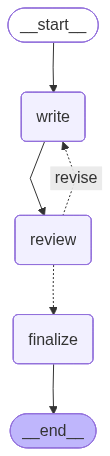

In [11]:
# ============================================================
# Visualize the graph structure with Mermaid
# ============================================================
from IPython.display import Image, display

try:
    # Display as PNG image (requires graphviz)
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid diagram code
    print("Mermaid diagram for the Document Review workflow:")
    print(app.get_graph().draw_mermaid())

## ✅ Module 10 Summary

You've learned:
- ✅ LangGraph concepts: State, Nodes, Edges
- ✅ Building cyclic workflows (feedback loops)
- ✅ Conditional routing between nodes
- ✅ Multi-agent collaboration patterns
- ✅ `Annotated` state for message accumulation
- ✅ Human-in-the-loop with `interrupt` and checkpointing
- ✅ Graph visualization

### 🚀 Next: [Module 11 — LangSmith: Observability & Debugging](11_LangSmith_Observability.ipynb)